PRÁCTICA 2. ANÁLISI ESTADISTICO DE SEÑALES

In [25]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

Carga del archivo .mat

In [26]:
mat_data=sio.loadmat('signals.mat')
print("llavez encontradas en el archivo",[key for key in mat_data.keys() if not key.startswith('__')])

llavez encontradas en el archivo ['Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2']


1.A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las señales, cree un vector de tiempo. 

In [27]:
fs=1024 #Frecuencia de muestreo
#Extraer señales
sin_filtrar=mat_data['ECG_asRecording'].squeeze()
filtrada=mat_data['ECG_filtered'].squeeze()

#Número total de muestras
n_muestras=len(sin_filtrar)

#Crear el vector de tiempo
tiempo=np.arange(n_muestras)/fs

print(f"Número de muestras: {n_muestras}")
print(f"Duración total del registro: {n_muestras/fs:.2f} segundos")


Número de muestras: 30720
Duración total del registro: 30.00 segundos


2.Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.

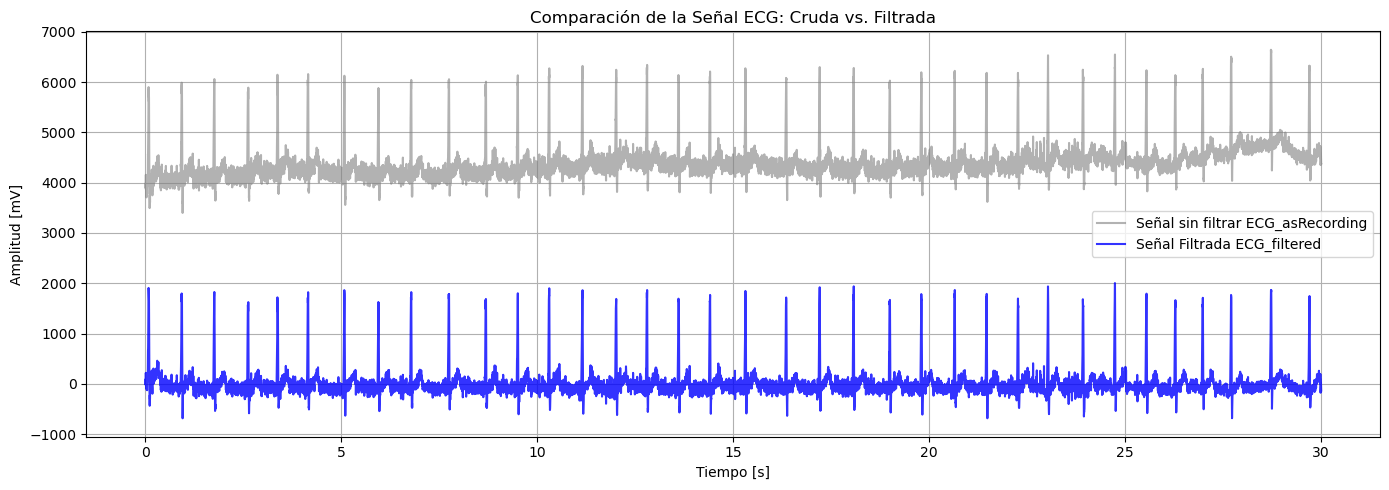

In [28]:
plt.figure(figsize=(14,5))
plt.plot(tiempo,sin_filtrar,label='Señal sin filtrar ECG_asRecording', alpha=0.6,color='gray')
plt.plot(tiempo,filtrada, label='Señal Filtrada ECG_filtered', alpha=0.8, color='blue')
plt.title('Comparación de la Señal ECG: Cruda vs. Filtrada')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

3.Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.

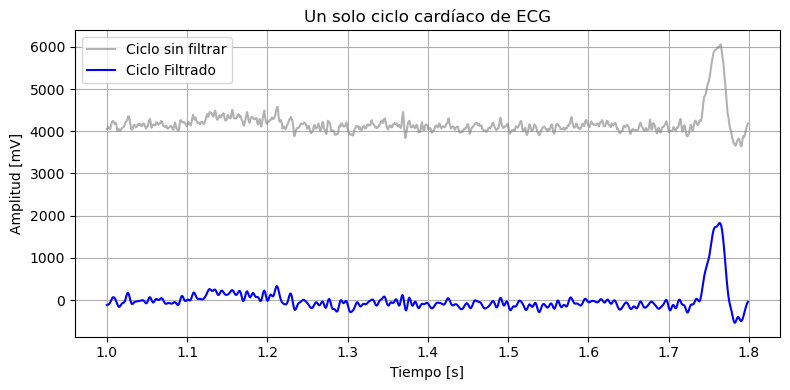

ESTADÍSTICOS CICLO SIN FILTRAR
Media: 4180.9677
Varianza: 89522.2342
Desviación Estándar: 299.2027
RMS: 4191.6599

ESTADÍSTICOS CICLO FILTRADO
Media: -9.5482
Varianza: 87970.0260
Desviación Estándar: 296.5974
RMS: 296.7511


In [29]:
#Función para calcular el  RSM
def calcular_rsm(signal):
    return np.sqrt(np.mean(signal**2))

#Selección de un solo ciclo cardíaco (ventana entre t=1.0s y t=1.8s)
t_inicio,t_fin=1.0,1.8
idx_inicio,idx_fin= int(t_inicio*fs),int(t_fin*fs)

ciclo_sinfiltrar= sin_filtrar[idx_inicio:idx_fin]
ciclo_filtrada= filtrada[idx_inicio:idx_fin]
tiempo_ciclo= tiempo[idx_inicio:idx_fin]

#Graficar el ciclo aislado
plt.figure(figsize=(8,4))
plt.plot(tiempo_ciclo,ciclo_sinfiltrar,label='Ciclo sin filtrar',color= 'gray',alpha=0.6)
plt.plot (tiempo_ciclo, ciclo_filtrada,label='Ciclo Filtrado', color='blue')
plt.title('Un solo ciclo cardíaco de ECG')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#Impresión en consola de metricas estadisticas del ciclo 
print("ESTADÍSTICOS CICLO SIN FILTRAR")
print(f"Media: {np.mean(ciclo_sinfiltrar):.4f}")
print(f"Varianza: {np.var(ciclo_sinfiltrar):.4f}")
print(f"Desviación Estándar: {np.std(ciclo_sinfiltrar):.4f}")
print(f"RMS: {calcular_rsm(ciclo_sinfiltrar):.4f}")

print("\nESTADÍSTICOS CICLO FILTRADO")
print(f"Media: {np.mean(ciclo_filtrada):.4f}")
print(f"Varianza: {np.var(ciclo_filtrada):.4f}")
print(f"Desviación Estándar: {np.std(ciclo_filtrada):.4f}")
print(f"RMS: {calcular_rsm(ciclo_filtrada):.4f}")

4.Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria? 

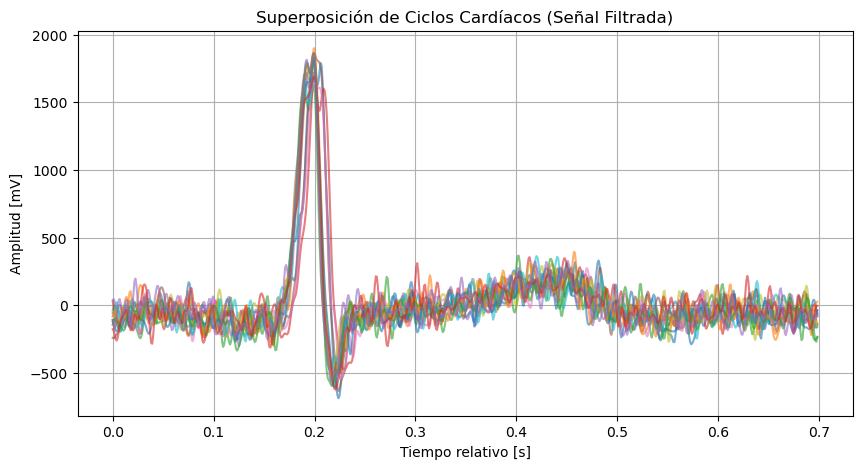

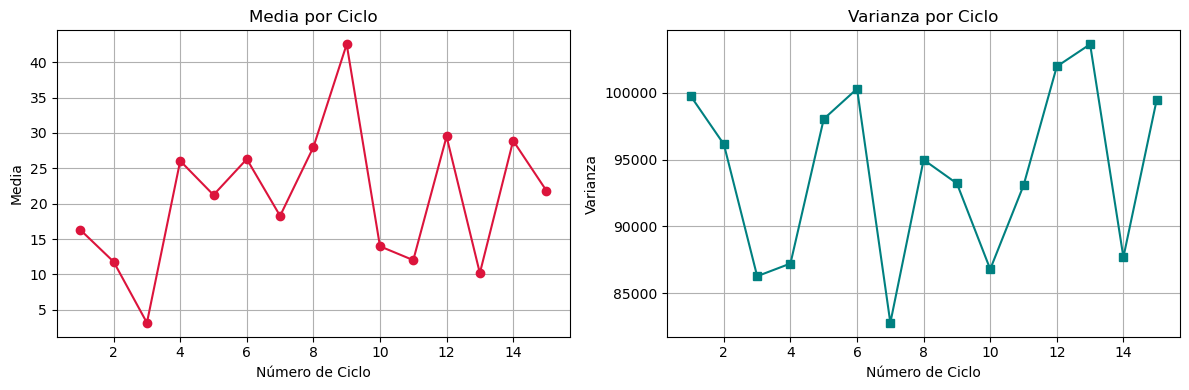

In [30]:
from scipy.signal import find_peaks

#Detección de picos R en la señal filtrada
picos_r, _ = find_peaks(filtrada, distance=int(fs * 0.6), height=np.max(filtrada) * 0.4)

#Definir ventana alrededor del pico R (0.2s antes y 0.5s después)
muestras_antes = int(0.2 * fs)
muestras_despues = int(0.5 * fs)

# Filtrar solo picos que permitan recortar la ventana completa ---
picos_validos = [p
    for p in picos_r
    if (p - muestras_antes >= 0) and (p + muestras_despues < len(filtrada))]

#Tomar hasta 15 picos que realmente tengan datos válidos
picos_15 = picos_validos[:15]

ciclos = []
medias = []
varianzas = []

plt.figure(figsize=(10, 5))

#Recortar los ciclos y calcular estadísticos
for i, pico in enumerate(picos_15):
  inicio = pico - muestras_antes
  fin = pico + muestras_despues

  ciclo = filtrada[inicio:fin]

  #Asegurar que el ciclo no esté vacío
  if len(ciclo) > 0:
    ciclos.append(ciclo)
    medias.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

    #Graficar cada ciclo superpuesto
    t_ciclo = np.arange(len(ciclo)) / fs
    plt.plot(t_ciclo, ciclo, alpha=0.6, label=f'Ciclo {i+1}' if i < 3 else '')

plt.title('Superposición de Ciclos Cardíacos (Señal Filtrada)')
plt.xlabel('Tiempo relativo [s]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.show()

#Graficar comportamiento de Media y Varianza
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

#Usar len(medias) para evitar descalce de dimensiones
eje_x = range(1, len(medias) + 1)

ax[0].plot(eje_x, medias, 'o-', color='crimson')
ax[0].set_title('Media por Ciclo')
ax[0].set_xlabel('Número de Ciclo')
ax[0].set_ylabel('Media')
ax[0].grid(True)

ax[1].plot(eje_x, varianzas, 's-', color='teal')
ax[1].set_title('Varianza por Ciclo')
ax[1].set_xlabel('Número de Ciclo')
ax[1].set_ylabel('Varianza')
ax[1].grid(True)

plt.tight_layout()
plt.show()


5.Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico (prueba U de Mann-Whitney).

6.Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal (Estacionariedad) 